In [1]:
import numpy as np
import pandas as pd

In [2]:
#Load the Dataset i.e Heart.csv
df=pd.read_csv('heart.csv')

Exploring the Dataset
 ->Understanding the dataset 

In [3]:
df.shape

(303, 14)

In [4]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

In [5]:
#Finding out all the different data types that are present in the DataSet
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [6]:
#Returns the head x rows if head(x) else default is 5 rows 
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [7]:
#If any column has null values then true is returned else false
df.isnull().any()

age         False
sex         False
cp          False
trestbps    False
chol        False
fbs         False
restecg     False
thalach     False
exang       False
oldpeak     False
slope       False
ca          False
thal        False
target      False
dtype: bool

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


Visualization of DATA

In [10]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [11]:
fig = plt.Figure(figsize=(15,15))
ax=fig.gca()
g=df.hist(ax=ax)

/tmp/ipykernel_531373/539130065.py:3: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  g=df.hist(ax=ax)


Text(0, 0.5, 'Count')

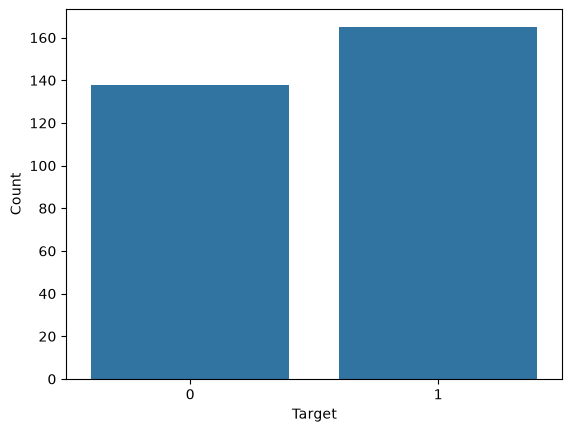

In [12]:


# Visualization to check if the dataset is balanced or not
g = sns.countplot(x='target', data=df)
plt.xlabel('Target')
plt.ylabel('Count')



Feature Engineering

<Axes: >

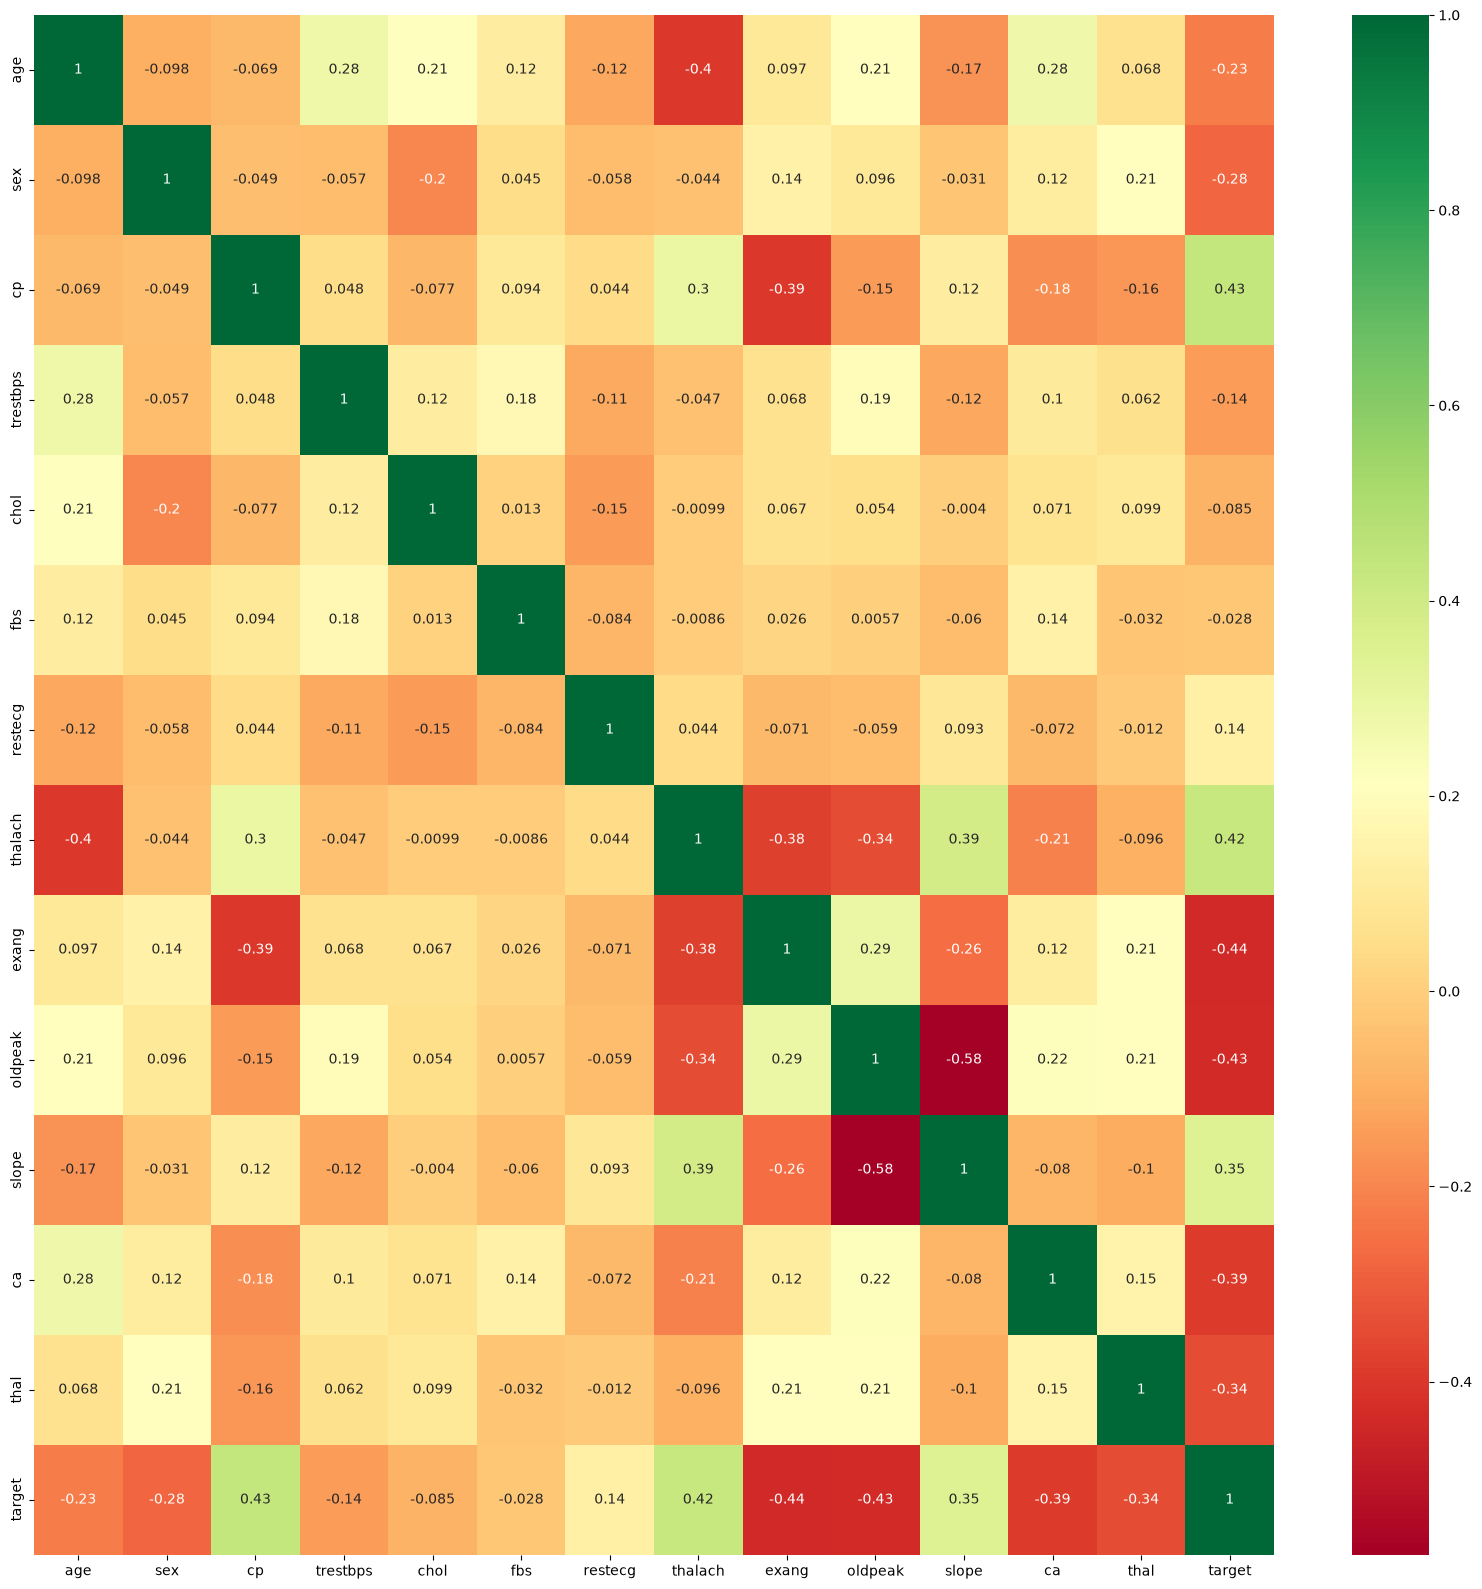

In [13]:
#Selecting Correlated features using heatmap

#Get correlation of all the features using the dataset

corr_matrix=df.corr()
top_corr_features=corr_matrix.index

#plotting the heartmap
plt.figure(figsize=(20,20))
sns.heatmap(data=df[top_corr_features].corr(),annot=True,cmap='RdYlGn')

Data Preprocessing

let's consider the column 'sex' here 0->Female and 1->Male these are just labels for us , but for the ML model it is just numbers
0->lower and 1->higher  but this has no meaning.

This kind of variable is called Nominal Categorical Feature

This causes a huge problem if not dealt with immediately 
Solution: One-Hot Encoding 
No ordering exists 
No numerical realtionship exists
The model simply checks : 
Is Female? Yes or No
Is Male? Yes or No


For algorithms that interpret feature values numerically (such as linear models, KNN, SVM, and neural networks), encoding nominal categories as integers can introduce an artificial ordering. One-hot encoding removes this false ordering by representing each category independently. Tree-based models are generally less affected by integer-coded categorical features.

In [14]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [15]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

In [16]:
dataset = pd.get_dummies(df,columns=['sex','cp','fbs','restecg','exang','slope','ca','thal'])
print(dataset)

     age  trestbps  chol  thalach  oldpeak  target  sex_0  sex_1   cp_0  \
0     63       145   233      150      2.3       1  False   True  False   
1     37       130   250      187      3.5       1  False   True  False   
2     41       130   204      172      1.4       1   True  False  False   
3     56       120   236      178      0.8       1  False   True  False   
4     57       120   354      163      0.6       1   True  False   True   
..   ...       ...   ...      ...      ...     ...    ...    ...    ...   
298   57       140   241      123      0.2       0   True  False   True   
299   45       110   264      132      1.2       0  False   True  False   
300   68       144   193      141      3.4       0  False   True   True   
301   57       130   131      115      1.2       0  False   True   True   
302   57       130   236      174      0.0       0   True  False  False   

      cp_1  ...  slope_2   ca_0   ca_1   ca_2   ca_3   ca_4  thal_0  thal_1  \
0    False  ...    F

In [17]:
dataset.columns

Index(['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'target', 'sex_0',
       'sex_1', 'cp_0', 'cp_1', 'cp_2', 'cp_3', 'fbs_0', 'fbs_1', 'restecg_0',
       'restecg_1', 'restecg_2', 'exang_0', 'exang_1', 'slope_0', 'slope_1',
       'slope_2', 'ca_0', 'ca_1', 'ca_2', 'ca_3', 'ca_4', 'thal_0', 'thal_1',
       'thal_2', 'thal_3'],
      dtype='str')

In [18]:
from sklearn.preprocessing import StandardScaler
standardScaler=StandardScaler()
columns_to_scale=['age','trestbps','chol','thalach','oldpeak']
dataset[columns_to_scale] = standardScaler.fit_transform(dataset[columns_to_scale])

In [19]:
dataset.head()

,age,trestbps,chol,thalach,oldpeak,target,sex_0,sex_1,cp_0,cp_1,...,slope_2,ca_0,ca_1,ca_2,ca_3,ca_4,thal_0,thal_1,thal_2,thal_3
0,0.952197,0.763956,-0.256334,0.015443,1.087338,1,False,True,False,False,...,False,True,False,False,False,False,False,True,False,False
1,-1.915313,-0.092738,0.072199,1.633471,2.122573,1,False,True,False,False,...,False,True,False,False,False,False,False,False,True,False
2,-1.474158,-0.092738,-0.816773,0.977514,0.310912,1,True,False,False,True,...,True,True,False,False,False,False,False,False,True,False
3,0.180175,-0.663867,-0.198357,1.239897,-0.206705,1,False,True,False,True,...,True,True,False,False,False,False,False,False,True,False
4,0.290464,-0.663867,2.082050,0.583939,-0.379244,1,True,False,True,False,...,True,True,False,False,False,False,False,False,True,False


In [20]:
X= dataset.drop('target',axis=1)
y=dataset['target']

MODEL BUILDING

I will be using 4 algorithms:

1.KNearestNeighbours

2.Decision Trees

3.Random Forest Classifier 

4.Logistic Regression

KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

In [22]:
# Stratified Cross Validation
cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)


In [33]:
# Test K values from 1 to 20
knn_scores=[]
for k in range(1, 21):

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])

    scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    )

    knn_scores.append(scores.mean())


In [34]:
print(knn_scores)

[np.float64(0.7587096774193548), np.float64(0.7755913978494624), np.float64(0.8149462365591399), np.float64(0.8249462365591398), np.float64(0.817956989247312), np.float64(0.8212903225806454), np.float64(0.8212903225806454), np.float64(0.8313978494623656), np.float64(0.8313978494623656), np.float64(0.8411827956989247), np.float64(0.8476344086021506), np.float64(0.8410752688172044), np.float64(0.8377419354838709), np.float64(0.8410752688172044), np.float64(0.8344086021505378), np.float64(0.8278494623655914), np.float64(0.8376344086021505), np.float64(0.8310752688172045), np.float64(0.830967741935484), np.float64(0.8344086021505378)]


In [35]:
# Find the best K from knn_scores 
best_k = knn_scores.index(max(knn_scores)) + 1
best_score = max(knn_scores)

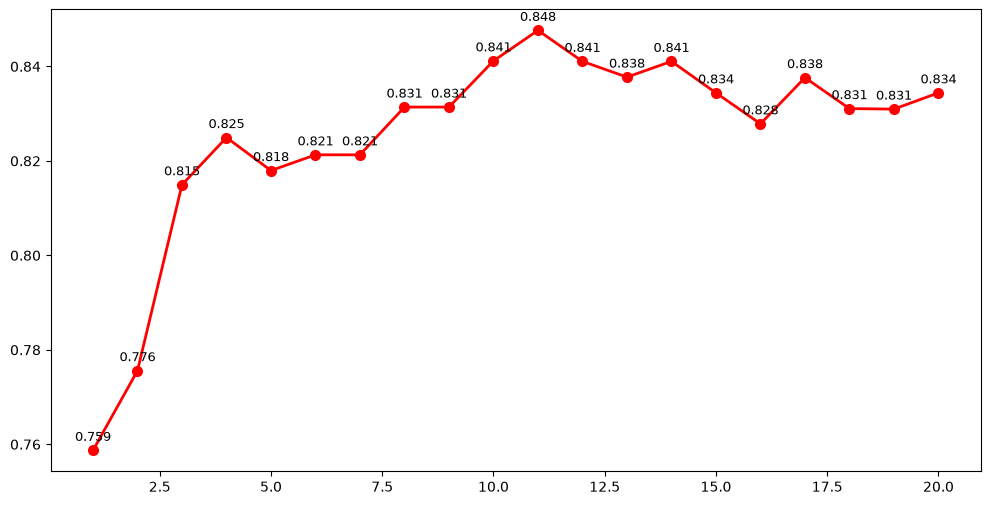

In [36]:
# Plot
plt.figure(figsize=(12, 6))

plt.plot(
    range(1, 21),
    knn_scores,
    color="red",
    marker="o",
    linewidth=2,
    markersize=7
)

# Annotate every point
for k, score in enumerate(knn_scores, start=1):
    plt.text(
        k,
        score + 0.002,
        f"{score:.3f}",
        ha="center",
        fontsize=9
    )


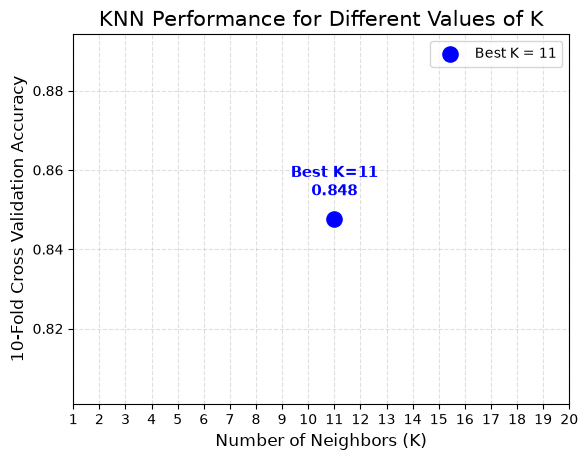

Best K      : 11
Best Score  : 0.8476


In [37]:
# Highlight the best K
plt.scatter(
    best_k,
    best_score,
    color="blue",
    s=120,
    zorder=5,
    label=f"Best K = {best_k}"
)

plt.text(
    best_k,
    best_score + 0.006,
    f"Best K={best_k}\n{best_score:.3f}",
    ha="center",
    color="blue",
    fontsize=11,
    fontweight="bold"
)

plt.xticks(range(1, 21))
plt.xlabel("Number of Neighbors (K)", fontsize=12)
plt.ylabel("10-Fold Cross Validation Accuracy", fontsize=12)
plt.title("KNN Performance for Different Values of K", fontsize=15)

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()

plt.show()

print(f"Best K      : {best_k}")
print(f"Best Score  : {best_score:.4f}")

In [48]:
best_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=best_k))
])

cv_scores = cross_val_score(
    best_pipeline,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print(f"KNN Accuracy with K={best_k} : {cv_scores.mean()*100:.2f}%")
print(f"Individual Fold Scores : {cv_scores}")
print(f"Mean Accuracy          : {cv_scores.mean():.4f}")
print(f"Standard Deviation     : {cv_scores.std():.4f}")



KNN Accuracy with K=11 : 84.76%
Individual Fold Scores : [0.90322581 0.90322581 0.90322581 0.86666667 0.66666667 0.8
 0.93333333 0.73333333 0.9        0.86666667]
Mean Accuracy          : 0.8476
Standard Deviation     : 0.0826


Decision Tree Classifier

In [50]:
from sklearn.tree import DecisionTreeClassifier

In [53]:
decision_scores=[]
for i in range(1,11):
    decision_classifier=DecisionTreeClassifier(max_depth=i)
    cvs_scores=cross_val_score(decision_classifier,X,y,cv=10)
    decision_scores.append(round(cvs_scores.mean(),3))

Text(0.5, 1.0, 'Decision Tree Classifier scores for different depth values')

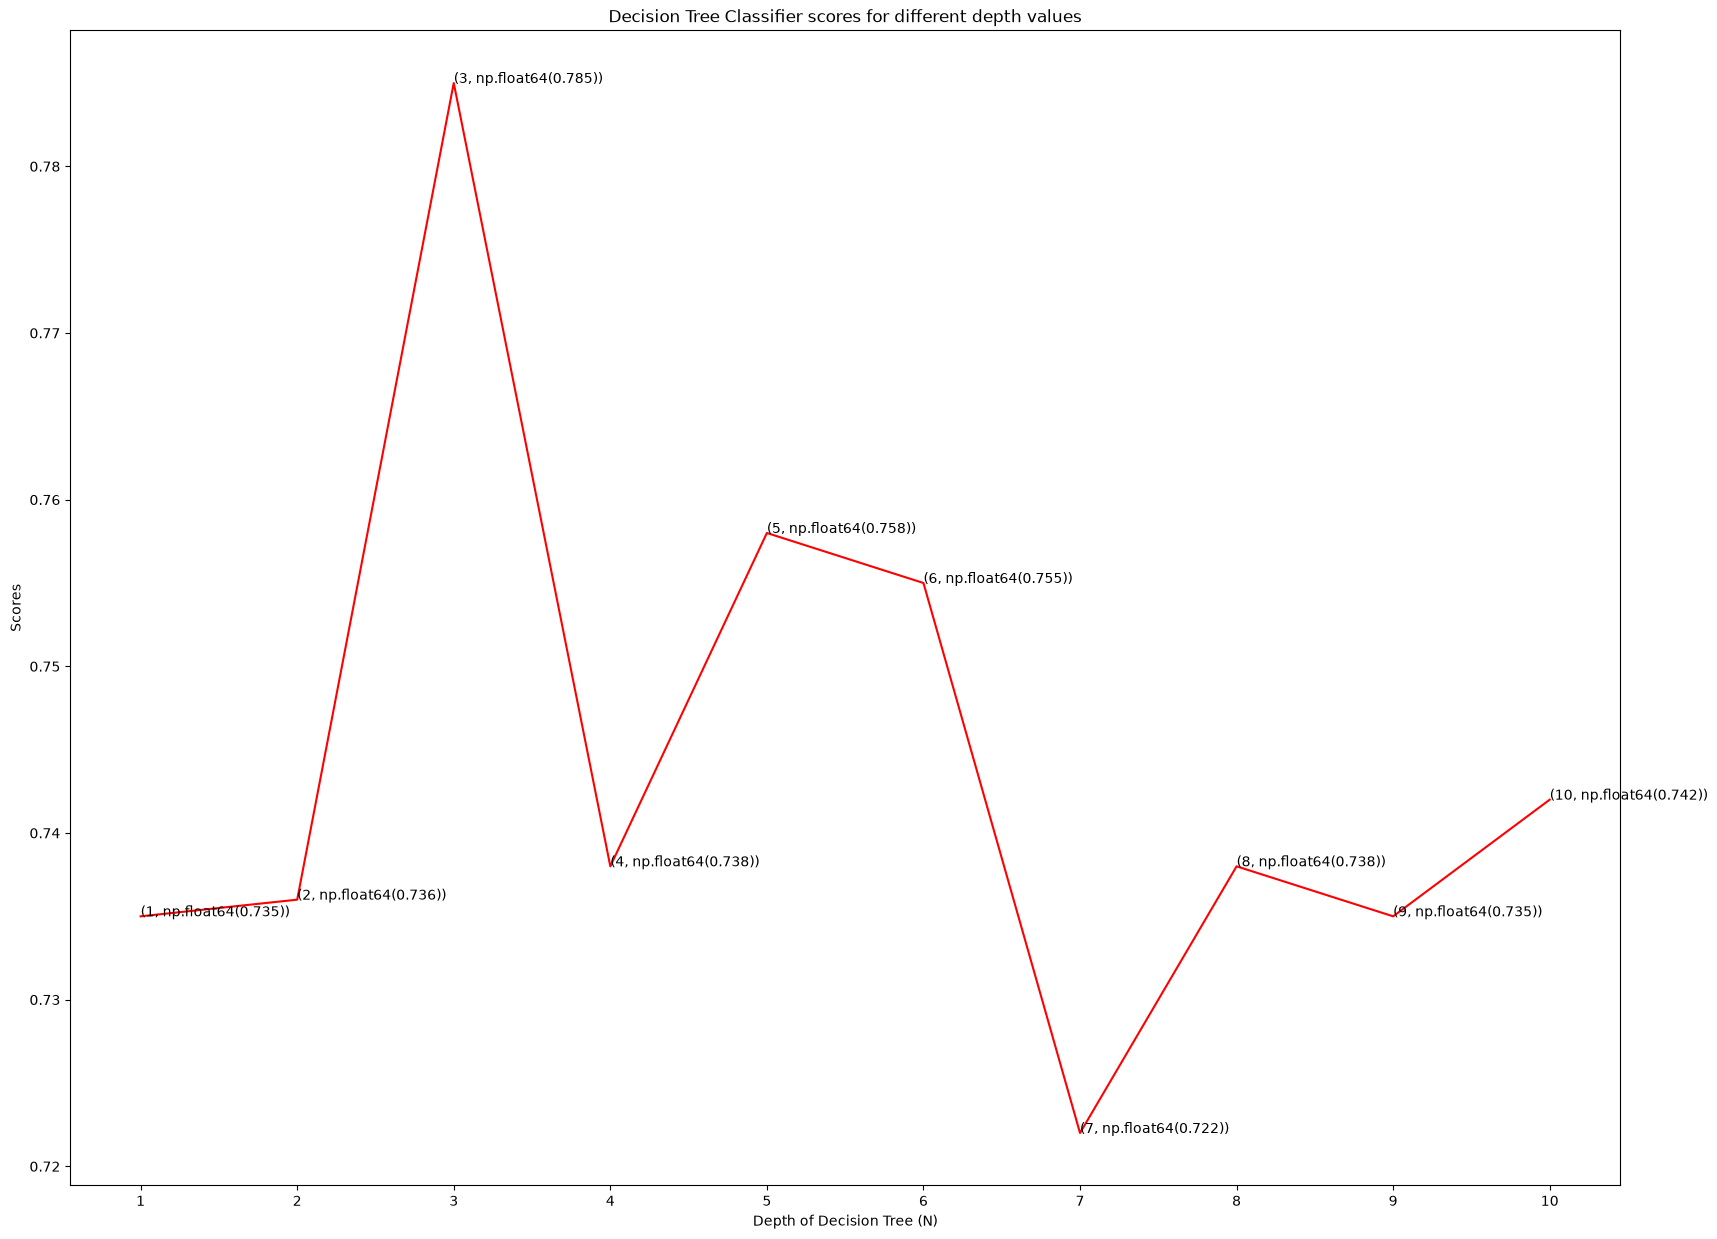

In [54]:
plt.figure(figsize=(20,15))
plt.plot([i for i in range(1, 11)], decision_scores, color = 'red')
for i in range(1,11):
    plt.text(i, decision_scores[i-1], (i, decision_scores[i-1]))
plt.xticks([i for i in range(1, 11)])
plt.xlabel('Depth of Decision Tree (N)')
plt.ylabel('Scores')
plt.title('Decision Tree Classifier scores for different depth values')

In [55]:
# Training the decision tree classifier model with max_depth value as 3
decision_classifier = DecisionTreeClassifier(max_depth=3)
cvs_scores = cross_val_score(decision_classifier, X, y, cv=10)
print("Decision Tree Classifier Accuracy with max_depth=3 is: {}%".format(round(cvs_scores.mean(), 4)*100))



Decision Tree Classifier Accuracy with max_depth=3 is: 78.51%


Random Forest Classifier

In [56]:
from sklearn.ensemble import RandomForestClassifier


In [57]:
# Finding the best accuracy for random forest algorithm using cross_val_score 
forest_scores = []
for i in range(10, 101, 10):
  forest_classifier = RandomForestClassifier(n_estimators=i)
  cvs_scores = cross_val_score(forest_classifier, X, y, cv=5)
  forest_scores.append(round(cvs_scores.mean(),3))



Text(0.5, 1.0, 'Random Forest Classifier scores for different N values')

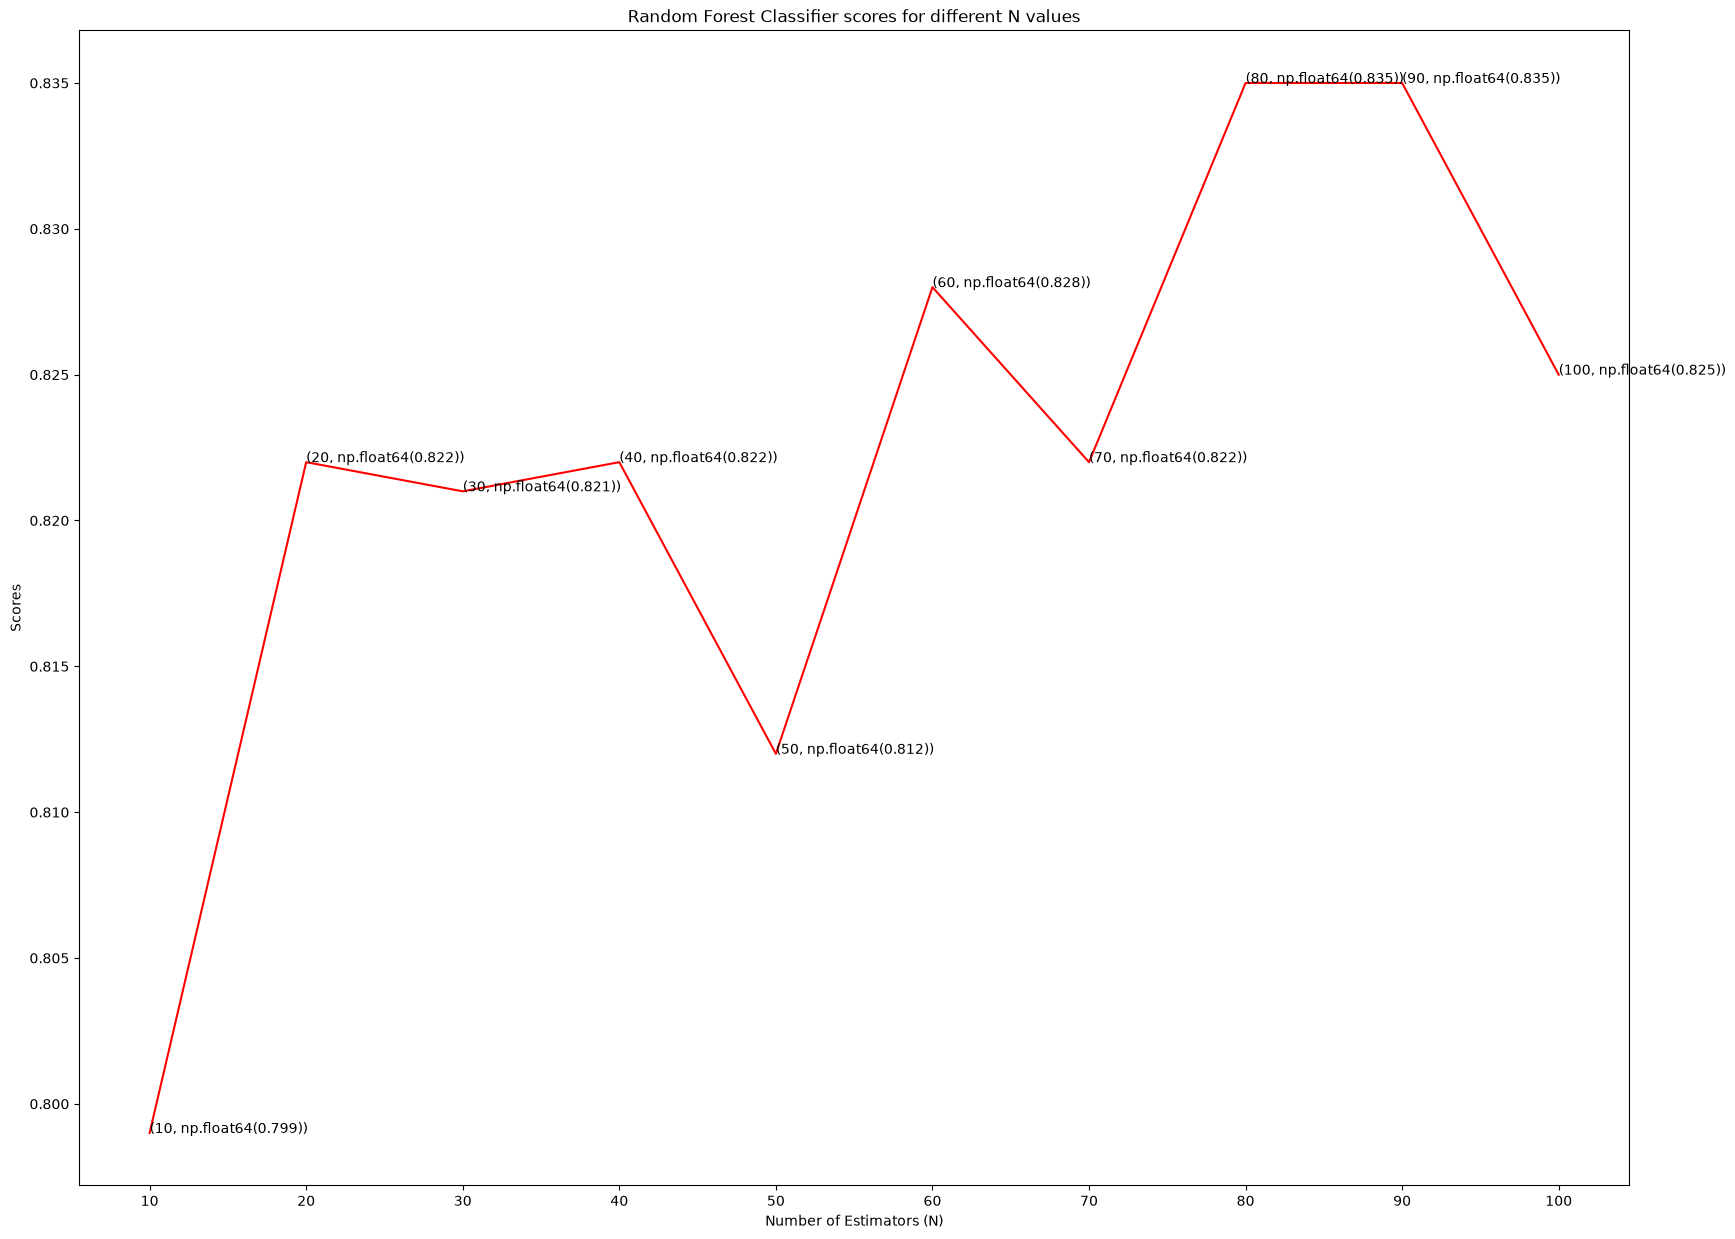

In [58]:
# Plotting the results of forest_scores
plt.figure(figsize=(20,15))
plt.plot([n for n in range(10, 101, 10)], forest_scores, color = 'red')
for i in range(1,11):
    plt.text(i*10, forest_scores[i-1], (i*10, forest_scores[i-1]))
plt.xticks([i for i in range(10, 101, 10)])
plt.xlabel('Number of Estimators (N)')
plt.ylabel('Scores')
plt.title('Random Forest Classifier scores for different N values')

In [61]:
# Training the random forest classifier model with n value as 90
forest_classifier = RandomForestClassifier(n_estimators=90)
cvs_scores = cross_val_score(forest_classifier, X, y, cv=5)
print("Random Forest Classifier Accuracy with n_estimators=90 is: {}%".format(round(cvs_scores.mean(), 4)*100))

Random Forest Classifier Accuracy with n_estimators=90 is: 83.83%


Optimised Random Forest

In [62]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    params,
    cv=10,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X, y)

print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
0.8515053763440861


In [63]:
print("=" * 50)
print("Random Forest - Best Model")
print("=" * 50)

print(f"Best Parameters : {grid.best_params_}")
print(f"Best Accuracy   : {grid.best_score_:.4f}")
print(f"Accuracy (%)    : {grid.best_score_ * 100:.2f}%")

Random Forest - Best Model
Best Parameters : {'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Best Accuracy   : 0.8515
Accuracy (%)    : 85.15%


Logistic Regression

In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Stratified 10-Fold Cross Validation
cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

In [65]:
# Logistic Regression Pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])

# Cross Validation
cv_scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)


In [66]:
print("=" * 50)
print("Logistic Regression Results")
print("=" * 50)
print(f"Individual Fold Scores : {cv_scores}")
print(f"Mean Accuracy          : {cv_scores.mean():.4f}")
print(f"Accuracy               : {cv_scores.mean()*100:.2f}%")
print(f"Standard Deviation     : {cv_scores.std():.4f}")

Logistic Regression Results
Individual Fold Scores : [0.90322581 0.96774194 0.87096774 0.86666667 0.76666667 0.76666667
 0.86666667 0.73333333 0.9        0.8       ]
Mean Accuracy          : 0.8442
Accuracy               : 84.42%
Standard Deviation     : 0.0706


Tuning the Model

In [67]:
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        random_state=42,
        max_iter=5000
    ))
])

param_grid = {
    "logreg__C": [0.01, 0.1, 1, 10, 100],
    "logreg__solver": ["liblinear", "lbfgs"],
    "logreg__penalty": ["l2"]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X, y)

/home/kafka/Coding/ML + GEN Ai/ML_In_depth/Projects/Heart Disease Prediction/Heart-Disease-Predictor/.Heart/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/kafka/Coding/ML + GEN Ai/ML_In_depth/Projects/Heart Disease Prediction/Heart-Disease-Predictor/.Heart/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', 

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'logreg__C': [0.01, 0.1, ...], 'logreg__penalty': ['l2'], 'logreg__solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",T

In [68]:
print("=" * 50)
print("Best Logistic Regression Model")
print("=" * 50)
print(f"Best Parameters : {grid.best_params_}")
print(f"Best Accuracy   : {grid.best_score_:.4f}")
print(f"Accuracy (%)    : {grid.best_score_ * 100:.2f}%")

Best Logistic Regression Model
Best Parameters : {'logreg__C': 0.1, 'logreg__penalty': 'l2', 'logreg__solver': 'lbfgs'}
Best Accuracy   : 0.8510
Accuracy (%)    : 85.10%


| Rank | Model                         |  Accuracy  |
| :--: | ----------------------------- | :--------: |
|  1   | Random Forest (Tuned)         | **85.15%** |
|  2   | Logistic Regression (Tuned)   | **85.10%** |
|  3   | K-Nearest Neighbors (KNN)     | **84.76%** |
|  4   | Logistic Regression (Default) | **84.42%** |
|  5   | Random Forest (Default)       | **83.83%** |
|  6   | Decision Tree                 | **78.51%** |


Key Observations:

Random Forest benefited the most from hyperparameter tuning, improving from 83.83% → 85.15%.

Logistic Regression also improved after tuning, reaching 85.10%, almost matching the tuned Random Forest.

KNN performed surprisingly well without an extensive hyperparameter search, finishing just behind the tuned models.

Decision Tree had the weakest performance, which is expected since a single tree often has higher variance than ensemble methods.